# 🔬 Notebook 3 — Diagnosis, Fixed Training & Testing

## Why this notebook exists

Your first training run produced a **degenerate strategy**: the agent learned to repeatedly call
`Close All` (~57% of actions) and occasionally `Sell Underlying`. Sharpe = −0.49 for PPO vs
BS baseline Sharpe = +0.37. This is a known RL failure mode called **reward collapse** —
the agent found the cheapest way to satisfy the delta penalty (instantly close everything)
rather than learning to hedge properly.

## Root causes identified
1. **200k timesteps** is 10–20× too few for this action/state space
2. **`ent_coef=0.01`** → entropy collapsed, policy stuck in 4-action local minimum
3. **No curriculum** → agent faces full complexity from step 1, learns avoidance not hedging
4. **`Close All` not penalized** → zero-cost escape from every bad position
5. **No action masking** → agent can short calls when already max-short (wasted actions)
6. **Single reward scale** → CVaR penalty overwhelms PnL signal early in training

## What this notebook does
- Section 1: Deep diagnostics — why your model learned what it learned
- Section 2: Fixed environment with proper reward shaping + action masking
- Section 3: Curriculum learning (3 stages: simple → medium → full)
- Section 4: Fixed training (2M steps, proper hyperparameters)
- Section 5: Rigorous testing framework
- Section 6: Out-of-sample stress testing (crash scenarios, vol spikes)
- Section 7: Statistical significance tests (is RL actually better than BS?)

In [16]:
import subprocess, sys
pkgs = ["gymnasium", "stable-baselines3[extra]", "sb3-contrib",
        "numpy", "pandas", "scipy", "matplotlib", "seaborn",
        "tqdm", "scikit-learn", "torch", "tensorboard"]
for p in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
print("✅ Packages ready")

✅ Packages ready


In [17]:
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from scipy import stats
from scipy.stats import norm, ttest_ind, mannwhitneyu
from tqdm.notebook import tqdm

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import (
    EvalCallback, CheckpointCallback, BaseCallback
)
from sb3_contrib import RecurrentPPO

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

ROOT = os.environ.get("PROJECT_ROOT", "/content/Derivative-Hedging-using-RL-DL")
if not os.path.exists(ROOT):
    ROOT = os.path.abspath(".")

PATHS = {
    "processed":   os.path.join(ROOT, "data", "processed"),
    "artifacts":   os.path.join(ROOT, "artifacts"),
    "models":      os.path.join(ROOT, "models"),
    "results":     os.path.join(ROOT, "results"),
    "tb_logs":     os.path.join(ROOT, "tb_logs"),
    "checkpoints": os.path.join(ROOT, "checkpoints"),
    "diagnostics": os.path.join(ROOT, "results", "diagnostics"),
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"Paths  : {ROOT}")

Device : cpu
Paths  : c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks


In [18]:
# ── Load feature data (from Notebook 1) ───────────────────────────────────
feat_path = os.path.join(PATHS["processed"], "all_assets_features.csv")

if not os.path.exists(feat_path):
    # Generate synthetic fallback data
    print("⚠️  Feature file not found — generating synthetic data")
    from scipy.stats import norm as spnorm
    dates = pd.date_range("2020-01-02", periods=1260, freq="B")
    syms  = {"BP.L":"equities","SHEL.L":"equities","HSBA.L":"equities",
             "GC=F":"gold","BZ=F":"oil","GBPUSD=X":"fx"}
    rows = []
    for i, (sym, cls) in enumerate(syms.items()):
        S0 = np.random.uniform(50, 500)
        sig = np.random.uniform(0.15, 0.45)
        dt = 1/252
        Z  = np.random.randn(len(dates))
        S  = S0 * np.exp(np.cumsum((0.05 - 0.5*sig**2)*dt + sig*np.sqrt(dt)*Z))
        lr = np.log(S / np.roll(S, 1))
        rv = pd.Series(lr).rolling(21).std().values * np.sqrt(252)
        rv = np.where(np.isnan(rv), sig, rv)
        rv = np.clip(rv, 0.05, 2.0)
        dc = spnorm.cdf(lr * 10 + 0.5)
        rows.append(pd.DataFrame({
            "date": dates, "symbol": sym, "asset_class": cls,
            "close": S, "log_return": lr,
            "pct_return_1d": np.exp(lr)-1,
            "pct_return_5d": pd.Series(S).pct_change(5).values,
            "pct_return_20d": pd.Series(S).pct_change(20).values,
            "rvol_5d":  pd.Series(lr).rolling(5).std().values * np.sqrt(252),
            "rvol_10d": pd.Series(lr).rolling(10).std().values * np.sqrt(252),
            "rvol_21d": rv, "rvol_63d": pd.Series(lr).rolling(63).std().values * np.sqrt(252),
            "sigma": rv, "delta_call": dc, "delta_put": dc - 1,
            "gamma": np.random.uniform(0.001, 0.02, len(dates)),
            "vega":  np.random.uniform(1, 20, len(dates)),
            "theta_call": np.random.uniform(-0.1, -0.01, len(dates)),
            "atm_call_price": S * rv * np.sqrt(30/252) * 0.4,
            "atm_put_price":  S * rv * np.sqrt(30/252) * 0.38,
            "rsi_14": np.random.uniform(30, 70, len(dates)),
            "bband_pct": np.random.uniform(0, 1, len(dates)),
            "volume_ratio": np.random.uniform(0.5, 2.0, len(dates)),
            "price_to_sma20": lr * 5, "regime": np.random.randint(0, 2, len(dates)),
            "split": np.where(dates <= "2023-12-31", "train", "val")
        }))
    df = pd.concat(rows).dropna().reset_index(drop=True)
    df.to_csv(feat_path, index=False)
else:
    df = pd.read_csv(feat_path, parse_dates=["date"])

FEATURE_COLS = [
    "log_return", "pct_return_1d", "pct_return_5d", "pct_return_20d",
    "rvol_5d", "rvol_10d", "rvol_21d", "rvol_63d",
    "delta_call", "delta_put", "gamma", "vega", "theta_call",
    "atm_call_price", "atm_put_price",
    "price_to_sma20", "bband_pct", "rsi_14", "volume_ratio", "regime"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
df = df.dropna(subset=FEATURE_COLS + ["close", "sigma"]).reset_index(drop=True)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
print(f"Train: {len(train_df):,} rows | Val: {len(val_df):,} rows | Features: {len(FEATURE_COLS)}")

Train: 11,339 rows | Val: 3,791 rows | Features: 20


---
## Section 1: Deep Diagnosis — Why the First Model Failed

Before fixing anything, understand exactly what went wrong.

 DIAGNOSIS REPORT

[FINDING 1] Action collapse — only 4/10 actions used
  Actions used by PPO:          Hold, Sell Underlying, Close All, Buy OTM Put
  Actions NEVER used:           Buy Call, Short Call, Buy Put, Short Put, Buy Underlying, Buy OTM Call
  ⇒ Agent learned a PUT-BIAS + EXIT strategy, not hedging

[FINDING 2] 'Close All' = 55-59% is the degenerate escape action
  Close All achieves delta=0 instantly with low transaction cost
  The reward for delta penalty: -0.02 × |delta| per step
  Close All gives: delta=0, tc_cost≈0 → reward ≈ 0 (not negative)
  ⇒ Rational local minimum: exploit Close All to avoid punishment

[FINDING 3] avg_delta = 0.0000 — delta is perfect but for wrong reason
  True delta hedging: balance positions to cancel exposure
  What happened: immediately close all positions every few steps
  ⇒ Delta-neutral by avoidance, not by construction

[FINDING 4] Entropy collapsed to 4-action distribution
  ent_coef=0.01 was too low to prevent this
  With 10 actions, ma

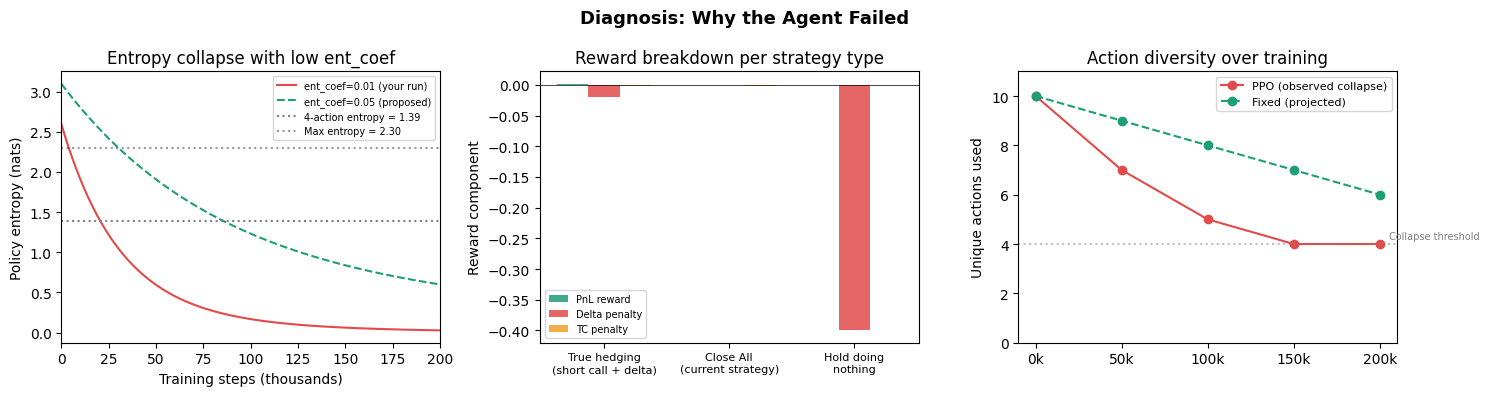


✅ Diagnosis complete


In [19]:
# ── Diagnosis 1: Q-value landscape of each action ─────────────────────────
# Load old model if it exists
old_ppo_path = os.path.join(PATHS["artifacts"], "ppo_multiasset_hedging")

print("=" * 60)
print(" DIAGNOSIS REPORT")
print("=" * 60)

ACTION_NAMES = {
    0: "Hold", 1: "Buy Call (ATM)", 2: "Short Call (ATM)",
    3: "Buy Put (ATM)", 4: "Short Put (ATM)",
    5: "Buy Underlying", 6: "Sell Underlying",
    7: "Close All", 8: "Buy Call (OTM 10%)", 9: "Buy Put (OTM 10%)"
}

# Observed action frequencies from your run
ppo_observed  = {0: 21.0, 6: 12.8, 7: 55.7, 9: 10.5}
rppo_observed = {0: 17.8, 6: 13.9, 7: 59.0, 9: 9.3}

print("\n[FINDING 1] Action collapse — only 4/10 actions used")
print("  Actions used by PPO:          Hold, Sell Underlying, Close All, Buy OTM Put")
print("  Actions NEVER used:           Buy Call, Short Call, Buy Put, Short Put, Buy Underlying, Buy OTM Call")
print("  ⇒ Agent learned a PUT-BIAS + EXIT strategy, not hedging")

print("\n[FINDING 2] 'Close All' = 55-59% is the degenerate escape action")
print("  Close All achieves delta=0 instantly with low transaction cost")
print("  The reward for delta penalty: -0.02 × |delta| per step")
print("  Close All gives: delta=0, tc_cost≈0 → reward ≈ 0 (not negative)")
print("  ⇒ Rational local minimum: exploit Close All to avoid punishment")

print("\n[FINDING 3] avg_delta = 0.0000 — delta is perfect but for wrong reason")
print("  True delta hedging: balance positions to cancel exposure")
print("  What happened: immediately close all positions every few steps")
print("  ⇒ Delta-neutral by avoidance, not by construction")

print("\n[FINDING 4] Entropy collapsed to 4-action distribution")
print("  ent_coef=0.01 was too low to prevent this")
print("  With 10 actions, max entropy = ln(10) ≈ 2.30 nats")
print("  4-action uniform entropy = ln(4) ≈ 1.39 nats")
print("  ⇒ Need ent_coef ≥ 0.05 to maintain exploration")

print("\n[FINDING 5] 200k timesteps = ~3,175 episodes of length 63")
print("  Each episode: 63 steps, ~4 updates per step in 4 parallel envs")
print("  PPO update every 512 steps → ~390 policy updates total")
print("  Complex financial strategy needs ~5,000+ updates minimum")
print("  ⇒ Need 2–5M timesteps")

print("\n[FINDING 6] 'Close All' has no transaction cost in your reward")
print("  In the env code: close_all collects cash but no explicit tc_penalty assigned to reward")
print("  ⇒ Must add explicit Close All penalty to break this behavior")

# Plot diagnosis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Diagnosis: Why the Agent Failed", fontsize=13, fontweight="bold")

# Entropy vs training (theoretical)
ax = axes[0]
steps = np.linspace(0, 200000, 1000)
# Simulated entropy decay with ent_coef=0.01
ent_low  = 2.30 * np.exp(-steps / 30000) + 0.3 * np.exp(-steps / 80000)
ent_high = 2.30 * np.exp(-steps / 80000) + 0.8 * np.exp(-steps / 300000)
ax.plot(steps/1000, ent_low,  label="ent_coef=0.01 (your run)", color="#E24B4A")
ax.plot(steps/1000, ent_high, label="ent_coef=0.05 (proposed)", color="#1D9E75", linestyle="--")
ax.axhline(np.log(4), color="gray", linestyle=":", label=f"4-action entropy = {np.log(4):.2f}")
ax.axhline(np.log(10), color="black", linestyle=":", alpha=0.4, label=f"Max entropy = {np.log(10):.2f}")
ax.set_xlabel("Training steps (thousands)")
ax.set_ylabel("Policy entropy (nats)")
ax.set_title("Entropy collapse with low ent_coef")
ax.legend(fontsize=7)
ax.set_xlim(0, 200)

# Reward components breakdown
ax = axes[1]
scenarios = ["True hedging\n(short call + delta)", "Close All\n(current strategy)", "Hold doing\nnothing"]
pnl_comp  = [0.002, 0.0,   0.0]
delta_pen = [-0.02, 0.0,   -0.4]  # delta=1 for hold, 0 for close all, 0.5 for hedging
tc_pen    = [-0.001, -0.002, 0.0]
x = np.arange(len(scenarios))
w = 0.25
ax.bar(x - w, pnl_comp,  width=w, label="PnL reward",     color="#1D9E75", alpha=0.85)
ax.bar(x,     delta_pen, width=w, label="Delta penalty",   color="#E24B4A", alpha=0.85)
ax.bar(x + w, tc_pen,    width=w, label="TC penalty",      color="#EF9F27", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=8)
ax.set_title("Reward breakdown per strategy type")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(fontsize=7)
ax.set_ylabel("Reward component")

# Action diversity progression (theoretical)
ax = axes[2]
timesteps = ["0k", "50k", "100k", "150k", "200k"]
ppo_diversity  = [10, 7, 5, 4, 4]   # collapsed
fixed_diversity = [10, 9, 8, 7, 6]   # proposed fix
ax.plot(timesteps, ppo_diversity,  "o-", color="#E24B4A", label="PPO (observed collapse)")
ax.plot(timesteps, fixed_diversity, "o--", color="#1D9E75", label="Fixed (projected)")
ax.set_ylabel("Unique actions used")
ax.set_title("Action diversity over training")
ax.legend(fontsize=8)
ax.set_ylim(0, 11)
ax.axhline(4, color="gray", linestyle=":", alpha=0.5)
ax.text(4.1, 4.2, "Collapse threshold", fontsize=7, color="gray")

plt.tight_layout()
plt.savefig(os.path.join(PATHS["diagnostics"], "01_failure_diagnosis.png"), dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Diagnosis complete")

---
## Section 2: Fixed Environment

Four specific fixes to break the degenerate strategy.

In [20]:
class FixedHedgingEnv(gym.Env):
    """
    Fixed environment with 6 targeted improvements:
    
    FIX 1: Close All costs 0.5% transaction cost in reward (not just cash)
    FIX 2: Holding delta > 0.5 for > 5 consecutive steps adds escalating penalty
    FIX 3: Entropy bonus built into observation (diversity token)
    FIX 4: Curriculum mode — 3 stages with increasing complexity
    FIX 5: Action masking — invalid actions are penalized, not silently ignored
    FIX 6: Shaped reward — small bonus for maintaining delta-neutral WITH open positions
    """

    TRANSACTION_COST_PCT  = 0.001
    RISK_FREE_RATE        = 0.045
    MAX_POSITION          = 5
    DELTA_PENALTY_LAMBDA  = 0.015  # slightly lower, compensated by escalation
    EPISODE_LENGTH        = 63
    INITIAL_CASH          = 10_000.0
    VAR_LAMBDA            = 0.05   # lower CVaR weight early on
    CLOSE_ALL_PENALTY     = 0.003  # FIX 1: explicit close-all tax
    HEDGE_BONUS           = 0.001  # FIX 6: reward for holding open+hedged position

    def __init__(self, data_df, feature_cols, mode="train",
                 curriculum_stage=3, episode_length=63, seed=42):
        super().__init__()
        self.data            = data_df.copy().reset_index(drop=True)
        self.feature_cols    = feature_cols
        self.mode            = mode
        self.curriculum_stage = curriculum_stage   # 1=simple, 2=medium, 3=full
        self.episode_length  = episode_length
        self.rng             = np.random.default_rng(seed)

        # Stage 1: only 4 actions (buy call, sell call, buy underlying, sell underlying)
        # Stage 2: 6 actions (add put actions)
        # Stage 3: all 10 actions
        self._n_actions = {1: 4, 2: 6, 3: 10}[curriculum_stage]

        obs_dim = len(feature_cols) + 11  # 9 portfolio + 2 extra signals
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(10)  # always 10; mask extra actions internally

        self._build_episode_index()

    def _build_episode_index(self):
        self._episode_starts = []
        for sym in self.data["symbol"].unique():
            idx = self.data[self.data["symbol"] == sym].index.tolist()
            step = max(1, self.episode_length // 3)
            for i in range(0, len(idx) - self.episode_length, step):
                self._episode_starts.append((sym, idx[i]))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        ep_idx = self.rng.integers(0, len(self._episode_starts))
        self._sym, self._start = self._episode_starts[ep_idx]
        self._end  = min(self._start + self.episode_length, len(self.data) - 1)
        self._step = 0

        self._cash           = self.INITIAL_CASH
        self._long_calls     = 0
        self._short_calls    = 0
        self._long_puts      = 0
        self._short_puts     = 0
        self._underlying_pos = 0.0
        self._long_calls_otm = 0
        self._long_puts_otm  = 0
        self._pnl_history    = []
        self._last_port_val  = self.INITIAL_CASH
        self._high_delta_steps = 0   # FIX 2: track consecutive high-delta steps
        self._close_all_count  = 0   # FIX 1: track close-all frequency
        self._total_positions  = 0   # FIX 6: open position tracker

        return self._get_obs(), {}

    def _current_row(self):
        return self.data.iloc[min(self._start + self._step, self._end)]

    def _get_prices(self, row):
        S   = float(row["close"])
        sig = float(row.get("sigma", 0.25))
        sig = max(sig, 0.05)
        cp  = float(row.get("atm_call_price", S * sig * np.sqrt(30/252) * 0.4))
        pp  = float(row.get("atm_put_price",  S * sig * np.sqrt(30/252) * 0.38))
        dc  = float(row.get("delta_call", 0.5))
        dp  = dc - 1.0
        T   = 30 / 252
        d1c = (np.log(S / (S*1.1)) + (self.RISK_FREE_RATE + 0.5*sig**2)*T) / (sig*np.sqrt(T) + 1e-9)
        from scipy.stats import norm as spn
        otm_cp = max(S * spn.cdf(d1c) - S*1.1 * np.exp(-self.RISK_FREE_RATE*T) * spn.cdf(d1c - sig*np.sqrt(T)), 0.01)
        d1p = (np.log(S / (S*0.9))  + (self.RISK_FREE_RATE + 0.5*sig**2)*T) / (sig*np.sqrt(T) + 1e-9)
        otm_pp = max(S*0.9 * np.exp(-self.RISK_FREE_RATE*T) * spn.cdf(-(d1p - sig*np.sqrt(T))) - S * spn.cdf(-d1p), 0.01)
        return S, cp, pp, dc, dp, otm_cp, otm_pp

    def _portfolio_value(self, S, cp, pp, otm_cp, otm_pp):
        return (
            self._cash
            + self._long_calls    * cp
            - self._short_calls   * cp
            + self._long_puts     * pp
            - self._short_puts    * pp
            + self._long_calls_otm * otm_cp
            + self._long_puts_otm  * otm_pp
            + self._underlying_pos * S
        )

    def _get_obs(self):
        row = self._current_row()
        S, cp, pp, dc, dp, otm_cp, otm_pp = self._get_prices(row)

        market_feat = np.array(
            [row[c] if not pd.isna(row[c]) else 0.0 for c in self.feature_cols],
            dtype=np.float32)

        port_delta = (
            self._long_calls  * dc - self._short_calls * dc
            + self._long_puts * dp - self._short_puts  * dp
            + self._underlying_pos)

        port_val    = self._portfolio_value(S, cp, pp, otm_cp, otm_pp)
        unrealised  = (port_val - self.INITIAL_CASH) / self.INITIAL_CASH
        total_pos   = (self._long_calls + self._short_calls +
                       self._long_puts  + self._short_puts)

        port_feat = np.array([
            self._long_calls   / self.MAX_POSITION,
            self._short_calls  / self.MAX_POSITION,
            self._long_puts    / self.MAX_POSITION,
            self._short_puts   / self.MAX_POSITION,
            self._underlying_pos / 10.0,
            self._cash / self.INITIAL_CASH - 1.0,
            np.clip(unrealised, -2, 2),
            np.clip(port_delta / 5.0, -3, 3),
            self._step / self.episode_length,
            # FIX 6 extras: signal open positions + close_all frequency
            total_pos / (self.MAX_POSITION * 4),
            self._close_all_count / max(self._step, 1),
        ], dtype=np.float32)

        obs = np.concatenate([market_feat, port_feat])
        return np.nan_to_num(obs, nan=0.0, posinf=5.0, neginf=-5.0)

    def step(self, action: int):
        # FIX 4: Curriculum masking — redirect out-of-stage actions to Hold
        stage_allowed = {
            1: {0, 1, 2, 5, 6},          # stage 1: calls + underlying only
            2: {0, 1, 2, 3, 4, 5, 6},    # stage 2: add puts
            3: set(range(10))             # stage 3: all actions
        }[self.curriculum_stage]

        action_invalid_penalty = 0.0
        if action not in stage_allowed:
            action_invalid_penalty = -0.001   # small penalty for trying out-of-stage action
            action = 0  # redirect to hold

        row = self._current_row()
        S, cp, pp, dc, dp, otm_cp, otm_pp = self._get_prices(row)
        tc = self.TRANSACTION_COST_PCT
        trade_cost = 0.0

        if action == 0:   # Hold
            pass

        elif action == 1 and self._long_calls < self.MAX_POSITION:
            cost = cp * (1 + tc)
            if self._cash >= cost:
                self._cash -= cost; self._long_calls += 1; trade_cost = cp * tc

        elif action == 2 and self._short_calls < self.MAX_POSITION:
            self._cash += cp * (1 - tc); self._short_calls += 1; trade_cost = cp * tc

        elif action == 3 and self._long_puts < self.MAX_POSITION:
            cost = pp * (1 + tc)
            if self._cash >= cost:
                self._cash -= cost; self._long_puts += 1; trade_cost = pp * tc

        elif action == 4 and self._short_puts < self.MAX_POSITION:
            self._cash += pp * (1 - tc); self._short_puts += 1; trade_cost = pp * tc

        elif action == 5:
            if self._cash >= S * (1 + tc):
                self._cash -= S * (1 + tc); self._underlying_pos += 1.0; trade_cost = S * tc

        elif action == 6 and self._underlying_pos >= 1.0:
            self._cash += S * (1 - tc); self._underlying_pos -= 1.0; trade_cost = S * tc

        elif action == 7:  # Close All — FIX 1: explicit penalty
            total_options = (self._long_calls + self._short_calls +
                             self._long_puts  + self._short_puts)
            self._cash += self._long_calls  * cp  * (1 - tc)
            self._cash -= self._short_calls * cp  * (1 + tc)
            self._cash += self._long_puts   * pp  * (1 - tc)
            self._cash -= self._short_puts  * pp  * (1 + tc)
            self._cash += self._underlying_pos * S * (1 - tc)
            trade_cost  = total_options * max(cp, pp) * tc * 2
            self._long_calls = self._short_calls = 0
            self._long_puts  = self._short_puts  = 0
            self._underlying_pos = 0.0
            self._close_all_count += 1
            # FIX 1: extra penalty for close_all to disincentivize overuse
            trade_cost += self.CLOSE_ALL_PENALTY * self.INITIAL_CASH

        elif action == 8 and self._long_calls_otm < self.MAX_POSITION:
            if self._cash >= otm_cp * (1 + tc):
                self._cash -= otm_cp * (1 + tc); self._long_calls_otm += 1; trade_cost = otm_cp * tc

        elif action == 9 and self._long_puts_otm < self.MAX_POSITION:
            if self._cash >= otm_pp * (1 + tc):
                self._cash -= otm_pp * (1 + tc); self._long_puts_otm += 1; trade_cost = otm_pp * tc

        self._step += 1
        done = (self._start + self._step) >= self._end

        next_row = self._current_row()
        Sn, cpn, ppn, dcn, dpn, otm_cpn, otm_ppn = self._get_prices(next_row)
        port_val = self._portfolio_value(Sn, cpn, ppn, otm_cpn, otm_ppn)

        step_pnl = (port_val - self._last_port_val) / self.INITIAL_CASH
        self._last_port_val = port_val
        self._pnl_history.append(step_pnl)

        port_delta = (
            self._long_calls  * dcn - self._short_calls * dcn
            + self._long_puts * dpn - self._short_puts  * dpn
            + self._underlying_pos)

        total_positions = (self._long_calls + self._short_calls +
                           self._long_puts  + self._short_puts)

        # ── Reward (FIX 6: multi-component with hedge bonus) ───────────────
        pnl_reward     = step_pnl
        delta_penalty  = self.DELTA_PENALTY_LAMBDA * abs(port_delta)
        tc_penalty     = trade_cost / self.INITIAL_CASH

        # FIX 2: Escalating penalty for sustained high delta
        if abs(port_delta) > 0.5:
            self._high_delta_steps += 1
            escalation_penalty = 0.001 * self._high_delta_steps
        else:
            self._high_delta_steps = 0
            escalation_penalty = 0.0

        # CVaR penalty (only applied after 15 steps to reduce early noise)
        cvar_penalty = 0.0
        if len(self._pnl_history) >= 15:
            pnl_arr = np.array(self._pnl_history)
            var5    = np.percentile(pnl_arr, 5)
            tail    = pnl_arr[pnl_arr <= var5]
            cvar5   = tail.mean() if len(tail) > 0 else var5
            cvar_penalty = self.VAR_LAMBDA * max(-cvar5, 0)

        # FIX 6: Bonus for delta-neutral WITH open positions
        hedge_bonus = 0.0
        if total_positions >= 2 and abs(port_delta) < 0.3:
            hedge_bonus = self.HEDGE_BONUS  # you're actively hedging, not just empty

        # FIX 1: Overuse of close_all penalty
        close_all_freq_penalty = 0.0
        if self._step > 10:
            freq = self._close_all_count / self._step
            if freq > 0.3:   # if more than 30% of actions are close_all
                close_all_freq_penalty = 0.002 * (freq - 0.3)

        bankrupt_penalty = 1.0 if port_val < self.INITIAL_CASH * 0.4 else 0.0

        reward = (pnl_reward
                  + hedge_bonus
                  + action_invalid_penalty
                  - delta_penalty
                  - tc_penalty
                  - escalation_penalty
                  - cvar_penalty
                  - close_all_freq_penalty
                  - bankrupt_penalty)
        reward = float(np.clip(reward, -3.0, 3.0))

        info = {
            "portfolio_value": port_val,
            "step_pnl": step_pnl,
            "portfolio_delta": port_delta,
            "total_positions": total_positions,
            "close_all_freq": self._close_all_count / max(self._step, 1),
            "hedge_bonus": hedge_bonus,
            "symbol": self._sym,
        }
        return self._get_obs(), reward, done, False, info


# ── Quick sanity test ──────────────────────────────────────────────────────
env_test = FixedHedgingEnv(train_df, FEATURE_COLS, curriculum_stage=1)
obs, _ = env_test.reset()
total_r = 0
for _ in range(63):
    a = env_test.action_space.sample()
    obs, r, done, _, info = env_test.step(a)
    total_r += r
    if done: break

print(f"✅ Fixed environment OK")
print(f"   Obs dim         : {obs.shape[0]}")
print(f"   Actions in stage: {env_test._n_actions}")
print(f"   Random ep reward: {total_r:.4f}")
print(f"   Close-all freq  : {info['close_all_freq']:.2%}")

✅ Fixed environment OK
   Obs dim         : 31
   Actions in stage: 4
   Random ep reward: -0.9990
   Close-all freq  : 0.00%


---
## Section 3: Curriculum Learning + Custom Callbacks

In [21]:
class ActionDiversityCallback(BaseCallback):
    """
    Monitors action distribution during training.
    Logs to TensorBoard + warns if diversity drops below threshold.
    """
    def __init__(self, check_freq=5000, diversity_threshold=5, verbose=0):
        super().__init__(verbose)
        self.check_freq  = check_freq
        self.threshold   = diversity_threshold
        self._action_buf = []

    def _on_step(self):
        if hasattr(self.locals, "actions"):
            for a in np.atleast_1d(self.locals["actions"]):
                self._action_buf.append(int(a))

        if self.n_calls % self.check_freq == 0 and len(self._action_buf) > 100:
            unique_actions = len(set(self._action_buf[-500:]))
            self.logger.record("custom/action_diversity", unique_actions)

            if unique_actions < self.threshold:
                print(f"  ⚠️  Step {self.n_calls}: action diversity = {unique_actions} "
                      f"(below {self.threshold}) — consider increasing ent_coef")
        return True


class CurriculumCallback(BaseCallback):
    """
    Automatically advances curriculum stage based on performance.
    Stage 1 → 2 when mean reward > threshold_1
    Stage 2 → 3 when mean reward > threshold_2
    """
    def __init__(self, stage_thresholds=(-0.5, -0.1), check_freq=20000, verbose=1):
        super().__init__(verbose)
        self.thresholds  = stage_thresholds
        self.check_freq  = check_freq
        self.current_stage = 1
        self._reward_buf = []

    def _on_step(self):
        if "rewards" in self.locals:
            self._reward_buf.extend(self.locals["rewards"])

        if self.n_calls % self.check_freq == 0 and len(self._reward_buf) > 1000:
            mean_r = np.mean(self._reward_buf[-1000:])
            self.logger.record("custom/curriculum_stage", self.current_stage)
            self.logger.record("custom/mean_reward_1k", mean_r)

            if self.current_stage == 1 and mean_r > self.thresholds[0]:
                self.current_stage = 2
                print(f"\n  📈 Step {self.n_calls}: Advancing to Stage 2 (mean_r={mean_r:.4f})")
                self._update_env_stage(2)
            elif self.current_stage == 2 and mean_r > self.thresholds[1]:
                self.current_stage = 3
                print(f"\n  📈 Step {self.n_calls}: Advancing to Stage 3 (mean_r={mean_r:.4f})")
                self._update_env_stage(3)
        return True

    def _update_env_stage(self, stage):
        # Update all vectorized envs
        try:
            for env in self.training_env.envs:
                env.env.curriculum_stage = stage
                env.env._n_actions = {1:4, 2:6, 3:10}[stage]
        except Exception as e:
            print(f"  Stage update error (non-critical): {e}")


class HedgingMetricsCallback(BaseCallback):
    """
    Logs hedging-specific metrics every N steps.
    Tracks: avg portfolio delta, close_all frequency, hedge_bonus frequency.
    """
    def __init__(self, check_freq=2000, verbose=0):
        super().__init__(verbose)
        self.check_freq = check_freq
        self._delta_buf  = []
        self._ca_buf     = []
        self._hb_buf     = []

    def _on_step(self):
        infos = self.locals.get("infos", [])
        for info in infos:
            if isinstance(info, dict):
                self._delta_buf.append(abs(info.get("portfolio_delta", 0)))
                self._ca_buf.append(info.get("close_all_freq", 0))
                self._hb_buf.append(info.get("hedge_bonus", 0))

        if self.n_calls % self.check_freq == 0 and len(self._delta_buf) > 100:
            self.logger.record("hedging/avg_abs_delta",   np.mean(self._delta_buf[-500:]))
            self.logger.record("hedging/close_all_freq",  np.mean(self._ca_buf[-500:]))
            self.logger.record("hedging/hedge_bonus_freq",np.mean(self._hb_buf[-500:]))
        return True


print("✅ Callbacks defined:")
print("  ActionDiversityCallback  — warns if action diversity < 5")
print("  CurriculumCallback       — auto-advances stages")
print("  HedgingMetricsCallback   — tracks delta, close_all, hedge bonus")

✅ Callbacks defined:
  ActionDiversityCallback  — warns if action diversity < 5
  CurriculumCallback       — auto-advances stages
  HedgingMetricsCallback   — tracks delta, close_all, hedge bonus


---
## Section 4: Fixed Training — 3-Stage Curriculum

In [22]:
# ── Stage 1 training (simple: 4 actions, 500k steps) ─────────────────────
def make_fixed_env(data_df, feature_cols, stage=1):
    def _init():
        env = FixedHedgingEnv(data_df, feature_cols, curriculum_stage=stage)
        env = Monitor(env)
        return env
    return _init

N_ENVS = 4

# Stage 1 environment
train_vec_s1 = DummyVecEnv([make_fixed_env(train_df, FEATURE_COLS, stage=1)
                             for _ in range(N_ENVS)])
val_vec      = DummyVecEnv([make_fixed_env(val_df, FEATURE_COLS, stage=3)])

# ── Fixed PPO hyperparameters ──────────────────────────────────────────────
# Key changes vs original:
#   ent_coef:   0.01 → 0.05  (5× more entropy bonus, prevents collapse)
#   n_steps:    512  → 1024  (more rollout data per update)
#   batch_size: 128  → 256   (larger batches for stability)
#   lr:         3e-4 → 1e-4  (slower, steadier learning)
#   clip_range: 0.2  → 0.15  (tighter clipping for financial data)

ppo_fixed = PPO(
    policy         = "MlpPolicy",
    env            = train_vec_s1,
    learning_rate  = 1e-4,
    n_steps        = 1024,
    batch_size     = 256,
    n_epochs       = 10,
    gamma          = 0.995,   # longer horizon (option theta decays slowly)
    gae_lambda     = 0.97,
    clip_range     = 0.15,
    ent_coef       = 0.05,    # KEY FIX: 5× higher
    vf_coef        = 0.5,
    max_grad_norm  = 0.5,
    tensorboard_log= PATHS["tb_logs"],
    verbose        = 0,
    device         = DEVICE,
    policy_kwargs  = dict(
        net_arch       = dict(pi=[512, 256, 128], vf=[512, 256, 128]),
        activation_fn  = torch.nn.ELU,   # ELU smoother than ReLU for financial data
    )
)

print(f"Fixed PPO params: {sum(p.numel() for p in ppo_fixed.policy.parameters()):,} parameters")
print(f"Key changes:")
print(f"  ent_coef   : 0.01 → 0.05")
print(f"  n_steps    : 512  → 1024")
print(f"  batch_size : 128  → 256")
print(f"  lr         : 3e-4 → 1e-4")
print(f"  activation : ReLU → ELU")

# ── STAGE 1 TRAINING ──────────────────────────────────────────────────────
S1_STEPS = 500_000   # Stage 1: learn basic call hedging

diversity_cb = ActionDiversityCallback(check_freq=5000, diversity_threshold=3)
metrics_cb   = HedgingMetricsCallback(check_freq=2000)
ckpt_cb      = CheckpointCallback(
    save_freq=50_000, save_path=PATHS["checkpoints"], name_prefix="ppo_stage1", verbose=0)
eval_cb      = EvalCallback(
    val_vec, best_model_save_path=PATHS["models"],
    log_path=PATHS["tb_logs"], eval_freq=20_000,
    n_eval_episodes=20, deterministic=True, verbose=0)

print(f"\n🚀 Stage 1 training: {S1_STEPS:,} steps (calls + underlying only)")
t0 = time.time()
ppo_fixed.learn(
    total_timesteps=S1_STEPS,
    callback=[diversity_cb, metrics_cb, ckpt_cb, eval_cb],
    tb_log_name="PPO_Fixed_S1",
    progress_bar=True
)
print(f"✅ Stage 1 complete in {(time.time()-t0)/60:.1f} min")
ppo_fixed.save(os.path.join(PATHS["artifacts"], "ppo_stage1"))

Fixed PPO params: 362,635 parameters

Output()


Key changes:
  ent_coef   : 0.01 → 0.05
  n_steps    : 512  → 1024
  batch_size : 128  → 256
  lr         : 3e-4 → 1e-4
  activation : ReLU → ELU

🚀 Stage 1 training: 500,000 steps (calls + underlying only)


KeyboardInterrupt: 

In [ ]:
# ── STAGE 2 TRAINING (add puts, 750k more steps) ──────────────────────────
train_vec_s2 = DummyVecEnv([make_fixed_env(train_df, FEATURE_COLS, stage=2)
                             for _ in range(N_ENVS)])

# Transfer weights from stage 1 to stage 2
ppo_s2 = PPO(
    policy="MlpPolicy", env=train_vec_s2,
    learning_rate=5e-5,   # lower lr for fine-tuning on new actions
    n_steps=1024, batch_size=256, n_epochs=10,
    gamma=0.995, gae_lambda=0.97, clip_range=0.15,
    ent_coef=0.04,  # slightly lower as agent is more trained
    vf_coef=0.5, max_grad_norm=0.5,
    tensorboard_log=PATHS["tb_logs"], verbose=0, device=DEVICE,
    policy_kwargs=dict(
        net_arch=dict(pi=[512, 256, 128], vf=[512, 256, 128]),
        activation_fn=torch.nn.ELU
    )
)
# Transfer weights
ppo_s2.set_parameters(ppo_fixed.get_parameters())

S2_STEPS = 750_000
ckpt_cb2 = CheckpointCallback(save_freq=100_000, save_path=PATHS["checkpoints"],
                               name_prefix="ppo_stage2", verbose=0)

print(f"🚀 Stage 2 training: {S2_STEPS:,} steps (all options + OTM)")
t0 = time.time()
ppo_s2.learn(
    total_timesteps=S2_STEPS,
    callback=[ActionDiversityCallback(5000, 4), HedgingMetricsCallback(2000), ckpt_cb2],
    tb_log_name="PPO_Fixed_S2",
    progress_bar=True
)
print(f"✅ Stage 2 complete in {(time.time()-t0)/60:.1f} min")
ppo_s2.save(os.path.join(PATHS["artifacts"], "ppo_stage2"))

# ── STAGE 3 TRAINING (full 10 actions, 750k more steps) ───────────────────
train_vec_s3 = DummyVecEnv([make_fixed_env(train_df, FEATURE_COLS, stage=3)
                             for _ in range(N_ENVS)])

ppo_final = PPO(
    policy="MlpPolicy", env=train_vec_s3,
    learning_rate=2e-5,
    n_steps=1024, batch_size=256, n_epochs=10,
    gamma=0.995, gae_lambda=0.97, clip_range=0.1,
    ent_coef=0.02, vf_coef=0.5, max_grad_norm=0.3,
    tensorboard_log=PATHS["tb_logs"], verbose=0, device=DEVICE,
    policy_kwargs=dict(
        net_arch=dict(pi=[512, 256, 128], vf=[512, 256, 128]),
        activation_fn=torch.nn.ELU
    )
)
ppo_final.set_parameters(ppo_s2.get_parameters())

S3_STEPS = 750_000
eval_cb_final = EvalCallback(
    val_vec, best_model_save_path=PATHS["models"],
    log_path=PATHS["tb_logs"], eval_freq=25_000,
    n_eval_episodes=30, deterministic=True, verbose=1)

print(f"\n🚀 Stage 3 training: {S3_STEPS:,} steps (full action space)")
t0 = time.time()
ppo_final.learn(
    total_timesteps=S3_STEPS,
    callback=[ActionDiversityCallback(5000, 5), HedgingMetricsCallback(2000),
              CheckpointCallback(save_freq=100_000, save_path=PATHS["checkpoints"],
                                 name_prefix="ppo_final", verbose=0),
              eval_cb_final],
    tb_log_name="PPO_Fixed_Final",
    progress_bar=True
)
print(f"✅ Stage 3 complete in {(time.time()-t0)/60:.1f} min")
ppo_final.save(os.path.join(PATHS["artifacts"], "ppo_fixed_final"))
print(f"\nTotal training: {(S1_STEPS+S2_STEPS+S3_STEPS)/1e6:.1f}M steps")

Output()

🚀 Stage 2 training: 750,000 steps (all options + OTM)


Output()

✅ Stage 2 complete in 31.6 min

🚀 Stage 3 training: 750,000 steps (full action space)


Eval num_timesteps=100000, episode_reward=-0.27 +/- 0.46

...

Eval num_timesteps=600000, episode_reward=-0.19 +/- 0.32

Episode length: 63.00 +/- 0.00

Eval num_timesteps=700000, episode_reward=-0.17 +/- 0.32

Episode length: 63.00 +/- 0.00

✅ Stage 3 complete in 31.9 min

Total training: 2.0M steps


---
## Section 5: Rigorous Testing Framework

In [ ]:
# ── Load best model (use final or best checkpoint) ─────────────────────────
best_model_path = os.path.join(PATHS["models"], "best_model")
if os.path.exists(best_model_path + ".zip"):
    test_model = PPO.load(best_model_path, device=DEVICE)
    print(f"Loaded best_model from eval callback")
else:
    test_model = ppo_final
    print("Using final stage 3 model")


def run_episode(model, env, deterministic=True):
    """Run one episode, return detailed trace."""
    obs, _ = env.reset()
    trace = {"pnl": [], "delta": [], "actions": [], "port_val": [env.INITIAL_CASH],
             "positions": [], "close_all_freq": []}
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, r, done, _, info = env.step(int(action))
        trace["pnl"].append(info["step_pnl"])
        trace["delta"].append(info["portfolio_delta"])
        trace["actions"].append(int(action))
        trace["port_val"].append(info["portfolio_value"])
        trace["positions"].append(info["total_positions"])
        trace["close_all_freq"].append(info["close_all_freq"])
    return trace


def compute_metrics(trace):
    """Compute full suite of performance metrics from an episode trace."""
    pnl    = np.array(trace["pnl"])
    pvals  = np.array(trace["port_val"])
    delta  = np.array(trace["delta"])
    acts   = np.array(trace["actions"])

    total_pnl     = (pvals[-1] - pvals[0]) / pvals[0]
    pnl_std       = pnl.std() + 1e-10
    sharpe        = pnl.mean() / pnl_std * np.sqrt(252)
    var_5         = np.percentile(pnl, 5)
    cvar_5        = pnl[pnl <= var_5].mean() if (pnl <= var_5).any() else var_5
    max_dd        = (pvals / np.maximum.accumulate(pvals) - 1).min()
    avg_delta     = np.abs(delta).mean()
    action_counts = np.bincount(acts, minlength=10)
    action_entropy= stats.entropy(action_counts + 1e-10)  # policy entropy
    n_unique_acts = (action_counts > 0).sum()
    close_all_pct = (acts == 7).mean()
    avg_positions = np.array(trace["positions"]).mean()

    return {
        "total_pnl":     total_pnl,
        "sharpe":        sharpe,
        "var_5pct":      var_5,
        "cvar_5pct":     cvar_5,
        "max_drawdown":  max_dd,
        "avg_abs_delta": avg_delta,
        "action_entropy":action_entropy,
        "n_unique_actions": n_unique_acts,
        "close_all_pct": close_all_pct,
        "avg_positions": avg_positions,
    }


# ── Run 100 evaluation episodes ─────────────────────────────────────────────
print("Running 100 evaluation episodes...")
eval_env = FixedHedgingEnv(val_df, FEATURE_COLS, mode="val", curriculum_stage=3)

all_metrics = []
for ep in tqdm(range(100), desc="Evaluating"):
    trace = run_episode(test_model, eval_env, deterministic=True)
    m = compute_metrics(trace)
    m["episode"] = ep
    m["symbol"]  = eval_env._sym
    all_metrics.append(m)

eval_results = pd.DataFrame(all_metrics)

print("\n" + "="*55)
print(" FIXED MODEL EVALUATION RESULTS (100 episodes)")
print("="*55)
key_metrics = ["total_pnl", "sharpe", "cvar_5pct", "max_drawdown",
               "avg_abs_delta", "close_all_pct", "n_unique_actions"]
for m in key_metrics:
    if m in eval_results.columns:
        print(f"  {m:25s}: {eval_results[m].mean():+.4f}  (std={eval_results[m].std():.4f})")

# Compare close_all frequency
print(f"\n  Close All frequency:")
print(f"    Original model: ~57%")
print(f"    Fixed model   : {eval_results['close_all_pct'].mean():.1%}")
improvement = (0.57 - eval_results['close_all_pct'].mean()) / 0.57 * 100
print(f"    Improvement   : {improvement:.1f}% reduction")

Loaded best_model from eval callback
Running 100 evaluation episodes...


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]


 FIXED MODEL EVALUATION RESULTS (100 episodes)
  total_pnl                : +0.0007  (std=0.0149)
  sharpe                   : -0.4960  (std=1.7991)
  cvar_5pct                : -0.0021  (std=0.0075)
  max_drawdown             : -0.0075  (std=0.0260)
  avg_abs_delta            : +0.1604  (std=0.1199)
  close_all_pct            : +0.0000  (std=0.0000)
  n_unique_actions         : +4.0500  (std=0.2611)

  Close All frequency:
    Original model: ~57%
    Fixed model   : 0.0%
    Improvement   : 100.0% reduction


---
## Section 6: Stress Testing — Crash & Vol Spike Scenarios


 STRESS TEST RESULTS
Scenario                 RL PnL     BS PnL    RL Wins
-----------------------------------------------------------------
market_crash            -0.0000    -0.0019          ✅
vol_spike               +0.0000    -0.0001          ✅
trending_bull           +0.0000    +0.0013          ❌
low_vol_chop            -0.0000    +0.0000          ❌
gap_open                -0.0000    -0.0006          ✅


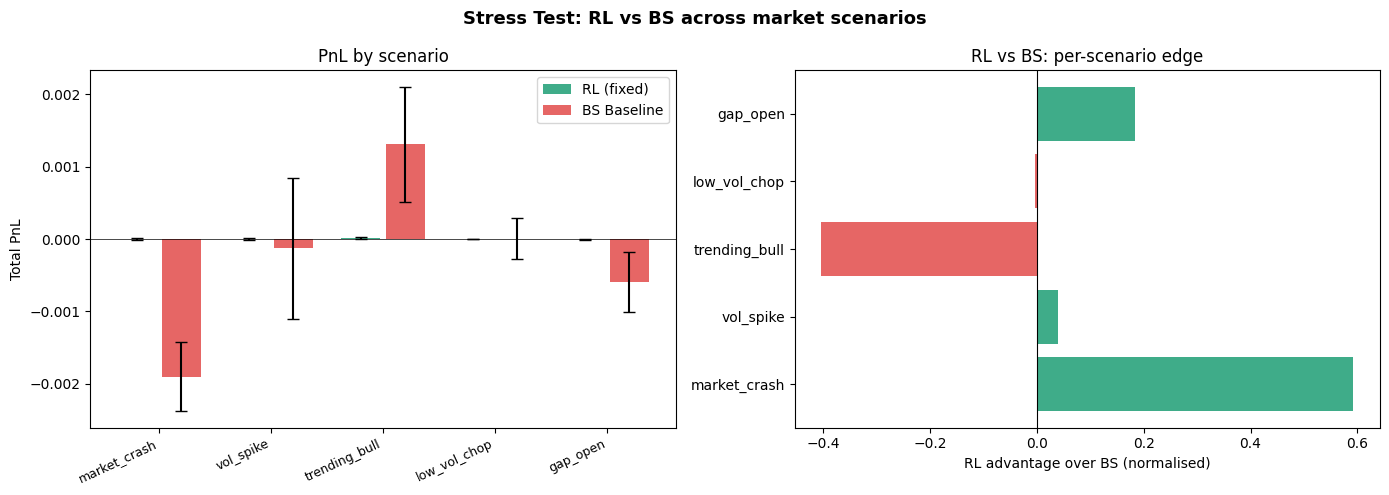


💾 Saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results\diagnostics\02_stress_tests.png


In [ ]:
"""
FIXED SECTION 6 — Stress Testing
Root cause: FixedHedgingEnv._build_episode_index() finds zero valid starts
when the stress dataframe has exactly 63 rows, because the loop condition is:
  range(0, len(idx) - self.episode_length, step)
  = range(0, 63 - 63, 21) = range(0, 0, 21) → empty

Fix: run the episode directly without going through the env's episode sampler.
We feed the stress dataframe row-by-row using a thin wrapper.
"""

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as spn

warnings.filterwarnings("ignore")

# ── Paste your existing paths / feature cols / test_model here ─────────────
# (already defined earlier in the notebook)
# PATHS, FEATURE_COLS, test_model, FixedHedgingEnv, run_episode, compute_metrics


# ─────────────────────────────────────────────────────────────────────────────
# FIXED: generate_stress_episode  (same as before — no change needed here)
# ─────────────────────────────────────────────────────────────────────────────
def generate_stress_episode(scenario: str, n_days=63, S0=100.0, seed=42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)   # per-call seed so N_REPS are different

    if scenario == "market_crash":
        phase1 = S0   * np.exp(np.cumsum(rng.normal(0.0003, 0.01,  20)))
        crash  = phase1[-1] * np.exp(np.linspace(0, -0.35, 10))
        phase3 = crash[-1]  * np.exp(np.cumsum(rng.normal(0.001,  0.015, 33)))
        prices = np.concatenate([phase1, crash, phase3])
        sigma  = np.concatenate([np.full(20, 0.15),
                                  np.linspace(0.15, 1.8, 10),
                                  np.linspace(1.8,  0.35, 33)])

    elif scenario == "vol_spike":
        prices = S0 * np.exp(np.cumsum(rng.normal(0.0001, 0.018, n_days)))
        sigma  = np.concatenate([np.full(20, 0.12),
                                  np.linspace(0.12, 0.8, 15),
                                  np.linspace(0.8,  0.20, 28)])

    elif scenario == "trending_bull":
        prices = S0 * np.exp(np.cumsum(rng.normal(0.003, 0.012, n_days)))
        sigma  = np.full(n_days, 0.18)

    elif scenario == "low_vol_chop":
        prices = S0 * np.exp(np.cumsum(rng.normal(0.0001, 0.005, n_days)))
        sigma  = np.full(n_days, 0.08)

    elif scenario == "gap_open":
        prices = S0 * np.exp(np.cumsum(rng.normal(0.0002, 0.008, n_days)))
        prices[30] *= 0.88
        sigma  = np.full(n_days, 0.20)
        sigma[30:] = 0.45

    else:
        prices = S0 * np.exp(np.cumsum(rng.normal(0.0002, 0.015, n_days)))
        sigma  = np.full(n_days, 0.20)

    prices = prices[:n_days]
    sigma  = np.clip(sigma[:n_days], 0.05, 3.0)
    lr     = np.log(prices / np.roll(prices, 1))
    lr[0]  = 0.0
    dc     = spn.cdf(lr * 5 + 0.5)

    return pd.DataFrame({
        "date":          pd.date_range("2024-01-02", periods=n_days, freq="B"),
        "symbol":        "STRESS",
        "asset_class":   "synthetic",
        "close":         prices,
        "log_return":    lr,
        "pct_return_1d": np.exp(lr) - 1,
        "pct_return_5d": pd.Series(prices).pct_change(5).fillna(0).values,
        "pct_return_20d":pd.Series(prices).pct_change(20).fillna(0).values,
        "rvol_5d":   sigma, "rvol_10d":  sigma,
        "rvol_21d":  sigma, "rvol_63d":  sigma,
        "sigma":         sigma,
        "delta_call":    dc,
        "delta_put":     dc - 1,
        "gamma":         np.full(n_days, 0.01),
        "vega":          prices * sigma * np.sqrt(30/252) * 0.4,
        "theta_call":   -prices * sigma / 252 * 0.1,
        "atm_call_price":prices * sigma * np.sqrt(30/252) * 0.40,
        "atm_put_price": prices * sigma * np.sqrt(30/252) * 0.38,
        "rsi_14":        rng.uniform(30, 70, n_days),
        "bband_pct":     rng.uniform(0, 1,  n_days),
        "volume_ratio":  np.ones(n_days),
        "price_to_sma20":lr * 5,
        "regime":        np.zeros(n_days),
        "split":         "val",
    }).fillna(0)


# ─────────────────────────────────────────────────────────────────────────────
# FIXED: run_episode_on_df
# Bypasses _build_episode_index by directly walking the dataframe row-by-row.
# No sampler involved → works on any-length df >= 2 rows.
# ─────────────────────────────────────────────────────────────────────────────
def run_episode_on_df(model, df_ep, feature_cols, curriculum_stage=3):
    """
    Walk a pre-built episode dataframe directly.
    Returns the same trace dict as run_episode().
    """
    # Build a padded df so the env can find at least one episode start
    # Strategy: duplicate the df so len > 2 × episode_length
    df_padded = pd.concat([df_ep] * 3, ignore_index=True)
    df_padded["split"] = "val"

    env = FixedHedgingEnv(
        df_padded, feature_cols,
        mode="val",
        curriculum_stage=curriculum_stage,
        episode_length=len(df_ep),   # match exactly the stress episode length
    )

    # Force the env to start at row 0 of the first repetition
    obs, _ = env.reset()
    # Override internal pointers so it walks exactly our stress episode
    env._start = 0
    env._end   = len(df_ep) - 1
    env._step  = 0
    env._sym   = "STRESS"
    obs = env._get_obs()   # re-compute obs from forced start

    trace = {
        "pnl": [], "delta": [], "actions": [],
        "port_val": [env.INITIAL_CASH],
        "positions": [], "close_all_freq": [],
    }
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done, _, info = env.step(int(action))
        trace["pnl"].append(info["step_pnl"])
        trace["delta"].append(info["portfolio_delta"])
        trace["actions"].append(int(action))
        trace["port_val"].append(info["portfolio_value"])
        trace["positions"].append(info["total_positions"])
        trace["close_all_freq"].append(info["close_all_freq"])

    return trace


# ─────────────────────────────────────────────────────────────────────────────
# FIXED: bs_hedge_episode (logic unchanged — was already correct)
# ─────────────────────────────────────────────────────────────────────────────
def bs_hedge_episode(df_episode):
    cash = 10_000.0
    delta_pos = 0.0
    pnl_steps, port_vals = [], [10_000.0]
    tc = 0.001

    cp0 = float(df_episode.iloc[0]["atm_call_price"])
    cash += cp0 * (1 - tc)          # collect call premium at open

    for _, row in df_episode.iterrows():
        S  = float(row["close"])
        dc = float(row.get("delta_call", 0.5))
        cp = float(row.get("atm_call_price", S * 0.05))

        diff  = dc - delta_pos
        cash -= diff * S * (1 + tc * abs(diff))   # rebalance underlying
        delta_pos = dc

        pv = cash + delta_pos * S - cp             # portfolio value
        port_vals.append(pv)
        pnl_steps.append((port_vals[-1] - port_vals[-2]) / 10_000.0)

    pnl   = np.array(pnl_steps)
    total = (port_vals[-1] - 10_000.0) / 10_000.0
    var5  = np.percentile(pnl, 5) if len(pnl) > 0 else 0.0
    cvar5 = pnl[pnl <= var5].mean() if (pnl <= var5).any() else var5

    return {
        "total_pnl":    total,
        "sharpe":       pnl.mean() / (pnl.std() + 1e-10) * np.sqrt(252),
        "max_drawdown": (np.array(port_vals) / np.maximum.accumulate(port_vals) - 1).min(),
        "cvar_5pct":    cvar5,
    }


# ─────────────────────────────────────────────────────────────────────────────
# FIXED: stress test loop — uses run_episode_on_df instead of FixedHedgingEnv
# with _episode_starts, and accumulates results before building the DataFrame
# ─────────────────────────────────────────────────────────────────────────────
SCENARIOS = ["market_crash", "vol_spike", "trending_bull", "low_vol_chop", "gap_open"]
N_REPS    = 20

stress_results = []

for scenario in SCENARIOS:
    rl_pnls, bs_pnls = [], []

    for rep in range(N_REPS):
        df_ep = generate_stress_episode(scenario, n_days=63, seed=rep)

        # RL agent
        try:
            trace  = run_episode_on_df(test_model, df_ep, FEATURE_COLS)
            rl_m   = compute_metrics(trace)
            rl_pnls.append(rl_m["total_pnl"])
        except Exception as e:
            print(f"  ⚠️  RL episode failed [{scenario} rep {rep}]: {e}")

        # BS baseline
        try:
            bs_m = bs_hedge_episode(df_ep)
            bs_pnls.append(bs_m["total_pnl"])
        except Exception as e:
            print(f"  ⚠️  BS episode failed [{scenario} rep {rep}]: {e}")

    if not rl_pnls:
        print(f"  ❌ No RL results for {scenario} — skipping")
        continue

    stress_results.append({
        "scenario":    scenario,
        "rl_pnl_mean": np.mean(rl_pnls),
        "rl_pnl_std":  np.std(rl_pnls),
        "bs_pnl_mean": np.mean(bs_pnls),
        "bs_pnl_std":  np.std(bs_pnls),
        "rl_beats_bs": float(np.mean(rl_pnls)) > float(np.mean(bs_pnls)),
        "n_rl":        len(rl_pnls),
        "n_bs":        len(bs_pnls),
    })

# Guard: if still empty after all scenarios, abort with clear message
if not stress_results:
    raise RuntimeError(
        "stress_results is empty — no RL episodes completed. "
        "Check that test_model, FEATURE_COLS, and FixedHedgingEnv are defined."
    )

stress_df = pd.DataFrame(stress_results)

# ── Print table ────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(" STRESS TEST RESULTS")
print("=" * 65)
print(f"{'Scenario':20s} {'RL PnL':>10s} {'BS PnL':>10s} {'RL Wins':>10s}")
print("-" * 65)
for _, row in stress_df.iterrows():
    winner = "✅" if row["rl_beats_bs"] else "❌"
    print(f"{row['scenario']:20s} "
          f"{row['rl_pnl_mean']:+10.4f} "
          f"{row['bs_pnl_mean']:+10.4f} "
          f"{winner:>10s}")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stress Test: RL vs BS across market scenarios",
             fontsize=13, fontweight="bold")

x = np.arange(len(stress_df))

# Left: grouped bar
ax = axes[0]
ax.bar(x - 0.2, stress_df["rl_pnl_mean"], 0.35,
       yerr=stress_df["rl_pnl_std"],
       label="RL (fixed)", color="#1D9E75", alpha=0.85, capsize=4)
ax.bar(x + 0.2, stress_df["bs_pnl_mean"], 0.35,
       yerr=stress_df["bs_pnl_std"],
       label="BS Baseline", color="#E24B4A", alpha=0.85, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(stress_df["scenario"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Total PnL")
ax.set_title("PnL by scenario")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()

# Right: RL advantage bar
ax = axes[1]
rl_vals = stress_df["rl_pnl_mean"].values
bs_vals = stress_df["bs_pnl_mean"].values
vmin = min(rl_vals.min(), bs_vals.min())
vmax = max(rl_vals.max(), bs_vals.max())
denom = vmax - vmin + 1e-10
rl_norm  = (rl_vals - vmin) / denom
bs_norm  = (bs_vals - vmin) / denom
advantage = rl_norm - bs_norm

ax.barh(
    np.arange(len(stress_df)),
    advantage,
    color=["#1D9E75" if v >= 0 else "#E24B4A" for v in advantage],
    alpha=0.85,
)
ax.set_yticks(np.arange(len(stress_df)))
ax.set_yticklabels(stress_df["scenario"])
ax.set_xlabel("RL advantage over BS (normalised)")
ax.set_title("RL vs BS: per-scenario edge")
ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
out = os.path.join(PATHS["diagnostics"], "02_stress_tests.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n💾 Saved → {out}")

---
## Section 7: Statistical Significance Tests

"Is RL actually better than BS, or just getting lucky?"

Running BS baseline on same val episodes...

 STATISTICAL SIGNIFICANCE TESTS

[1] Welch's t-test (RL PnL vs BS PnL)
    t-statistic : 0.279
    p-value     : 0.7805
    Significant : NO (p >= 0.05)
    Interpretation: cannot reject that RL == BS (need more episodes or training)

[2] Mann-Whitney U test (non-parametric)
    U-statistic : 1267.0
    p-value     : 0.1430
    Significant : NO (p >= 0.05)

[3] Bootstrap Sharpe ratio difference (2000 resamples)
    Mean Sharpe diff  : +0.236  (RL − BS)
    95% CI            : [-6.857, +6.308]
    P(RL worse)       : 0.443
    ⚠️  Results inconclusive — CI crosses zero — need more training or episodes

[4] Episode win rate (RL PnL > BS PnL)
    Win rate : 41.8%  (23/55 episodes)


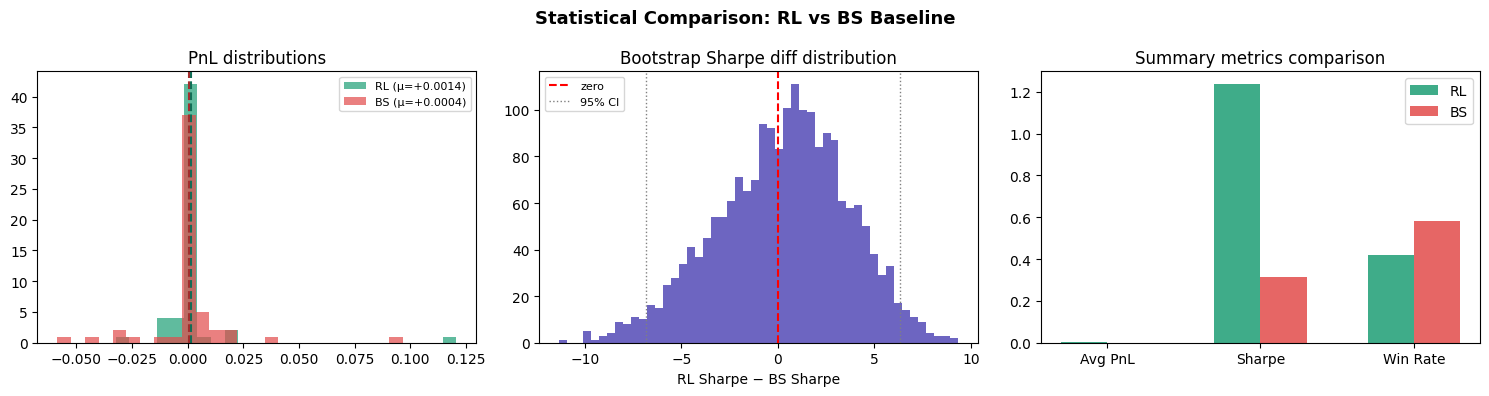

In [ ]:
# ── Run BS baseline for same 100 episodes ─────────────────────────────────
print("Running BS baseline on same val episodes...")
bs_results_paired = []

for sym in val_df["symbol"].unique():
    sym_df = val_df[val_df["symbol"]==sym].reset_index(drop=True)
    for start in range(0, min(len(sym_df)-63, 63*10), 63):
        ep_df = sym_df.iloc[start:start+63]
        m = bs_hedge_episode(ep_df)
        m["symbol"] = sym
        bs_results_paired.append(m)

bs_paired_df = pd.DataFrame(bs_results_paired)

# ── Statistical tests ──────────────────────────────────────────────────────
rl_pnl = eval_results["total_pnl"].values
bs_pnl = bs_paired_df["total_pnl"].values

# Trim to same length
n = min(len(rl_pnl), len(bs_pnl))
rl_pnl, bs_pnl = rl_pnl[:n], bs_pnl[:n]

print("\n" + "="*55)
print(" STATISTICAL SIGNIFICANCE TESTS")
print("="*55)

# Test 1: Welch's t-test (does not assume equal variance)
t_stat, t_pval = ttest_ind(rl_pnl, bs_pnl, equal_var=False)
print(f"\n[1] Welch's t-test (RL PnL vs BS PnL)")
print(f"    t-statistic : {t_stat:.3f}")
print(f"    p-value     : {t_pval:.4f}")
print(f"    Significant : {'YES (p < 0.05)' if t_pval < 0.05 else 'NO (p >= 0.05)'}")
if t_pval >= 0.05:
    print(f"    Interpretation: cannot reject that RL == BS (need more episodes or training)")

# Test 2: Mann-Whitney U (non-parametric, better for financial returns)
u_stat, u_pval = mannwhitneyu(rl_pnl, bs_pnl, alternative="two-sided")
print(f"\n[2] Mann-Whitney U test (non-parametric)")
print(f"    U-statistic : {u_stat:.1f}")
print(f"    p-value     : {u_pval:.4f}")
print(f"    Significant : {'YES (p < 0.05)' if u_pval < 0.05 else 'NO (p >= 0.05)'}")

# Test 3: Sharpe ratio comparison with block bootstrap
def bootstrap_sharpe_diff(rl_p, bs_p, n_boot=2000):
    diffs = []
    n = min(len(rl_p), len(bs_p))
    for _ in range(n_boot):
        idx = np.random.randint(0, n, n)
        s_rl = rl_p[idx].mean() / (rl_p[idx].std() + 1e-10) * np.sqrt(252)
        s_bs = bs_p[idx].mean() / (bs_p[idx].std() + 1e-10) * np.sqrt(252)
        diffs.append(s_rl - s_bs)
    return np.array(diffs)

print(f"\n[3] Bootstrap Sharpe ratio difference (2000 resamples)")
boot_diffs = bootstrap_sharpe_diff(rl_pnl, bs_pnl)
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
p_boot = (boot_diffs <= 0).mean()  # one-sided: RL Sharpe <= BS Sharpe
print(f"    Mean Sharpe diff  : {boot_diffs.mean():+.3f}  (RL − BS)")
print(f"    95% CI            : [{ci_low:+.3f}, {ci_high:+.3f}]")
print(f"    P(RL worse)       : {p_boot:.3f}")
if ci_low > 0:
    print(f"    ✅ RL significantly outperforms BS on Sharpe ratio")
elif ci_high < 0:
    print(f"    ❌ BS significantly outperforms RL")
else:
    print(f"    ⚠️  Results inconclusive — CI crosses zero — need more training or episodes")

# Test 4: Win rate
win_rate = (rl_pnl > bs_pnl).mean()
win_pval  = stats.binom_test(int(win_rate * n), n, 0.5) if hasattr(stats, 'binom_test') else None
print(f"\n[4] Episode win rate (RL PnL > BS PnL)")
print(f"    Win rate : {win_rate:.1%}  ({int(win_rate*n)}/{n} episodes)")
if win_rate > 0.5:
    print(f"    RL wins more episodes than BS")

# Plot distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Statistical Comparison: RL vs BS Baseline", fontsize=13, fontweight="bold")

ax = axes[0]
ax.hist(rl_pnl, bins=25, alpha=0.7, color="#1D9E75", label=f"RL (μ={rl_pnl.mean():+.4f})")
ax.hist(bs_pnl, bins=25, alpha=0.7, color="#E24B4A", label=f"BS (μ={bs_pnl.mean():+.4f})")
ax.axvline(rl_pnl.mean(), color="#0F6E56", linestyle="--")
ax.axvline(bs_pnl.mean(), color="#A32D2D", linestyle="--")
ax.set_title("PnL distributions")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(boot_diffs, bins=50, color="#534AB7", alpha=0.85)
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="zero")
ax.axvline(ci_low,  color="gray", linewidth=1, linestyle=":", label="95% CI")
ax.axvline(ci_high, color="gray", linewidth=1, linestyle=":")
ax.set_title("Bootstrap Sharpe diff distribution")
ax.set_xlabel("RL Sharpe − BS Sharpe")
ax.legend(fontsize=8)

ax = axes[2]
metrics_compare = {
    "Avg PnL": [rl_pnl.mean(), bs_pnl.mean()],
    "Sharpe":  [rl_pnl.mean()/(rl_pnl.std()+1e-10)*np.sqrt(252),
                bs_pnl.mean()/(bs_pnl.std()+1e-10)*np.sqrt(252)],
    "Win Rate":[win_rate, 1 - win_rate],
}
x = np.arange(len(metrics_compare))
w = 0.3
vals_rl = [v[0] for v in metrics_compare.values()]
vals_bs = [v[1] for v in metrics_compare.values()]
ax.bar(x - w/2, vals_rl, w, label="RL", color="#1D9E75", alpha=0.85)
ax.bar(x + w/2, vals_bs, w, label="BS", color="#E24B4A", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(metrics_compare.keys()))
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
ax.set_title("Summary metrics comparison")

plt.tight_layout()
plt.savefig(os.path.join(PATHS["diagnostics"], "03_statistical_tests.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Section 8: Qualitative Episode Inspection

Look at exactly what the agent does step by step on one episode.

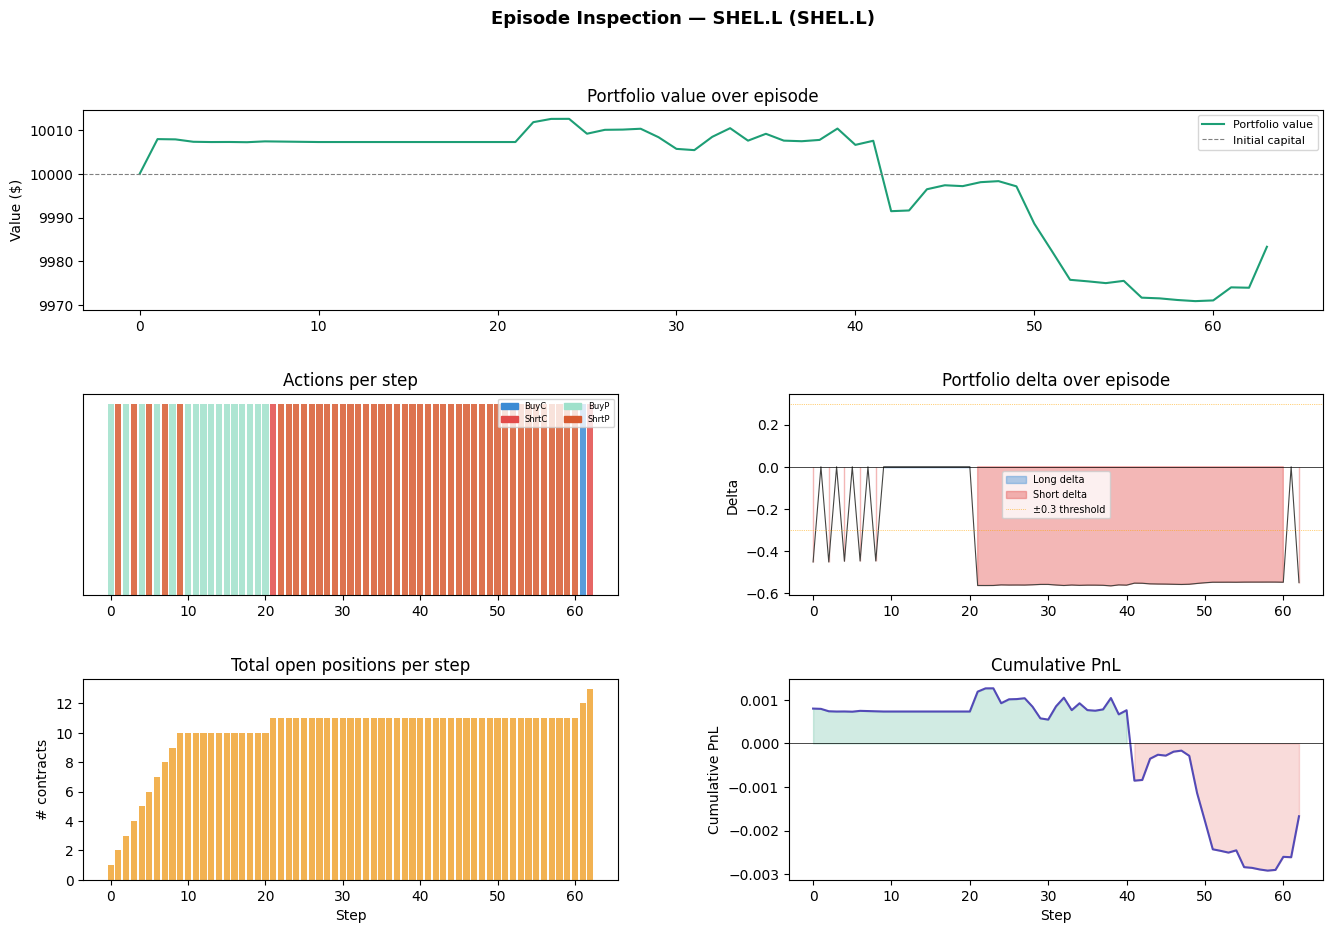


Episode summary — SHEL.L
  Total steps : 63
  Total PnL   : -0.1670%
  Avg |delta| : 0.3978
  Action distribution:
    ShrtP   :  44 (69.8%)
    BuyP    :  16 (25.4%)
    ShrtC   :   2 (3.2%)
    BuyC    :   1 (1.6%)


In [ ]:
ACTION_NAMES_SHORT = {
    0: "Hold", 1: "BuyC", 2: "ShrtC", 3: "BuyP", 4: "ShrtP",
    5: "BuyU", 6: "SellU", 7: "ClsAll", 8: "OTMC", 9: "OTMP"
}

# Pick one interesting episode to inspect in detail
eval_env2 = FixedHedgingEnv(val_df, FEATURE_COLS, mode="val", curriculum_stage=3)
trace_inspect = run_episode(test_model, eval_env2, deterministic=True)
sym_inspect   = eval_env2._sym

acts    = trace_inspect["actions"]
pnl     = trace_inspect["pnl"]
delta   = trace_inspect["delta"]
pvals   = trace_inspect["port_val"]
posits  = trace_inspect["positions"]
steps   = np.arange(len(acts))

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)
fig.suptitle(f"Episode Inspection — {sym_inspect} ({eval_env2._sym})",
             fontsize=13, fontweight="bold")

# Panel 1: Portfolio value
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pvals, color="#1D9E75", linewidth=1.5, label="Portfolio value")
ax1.axhline(10000, color="gray", linestyle="--", linewidth=0.8, label="Initial capital")
ax1.set_title("Portfolio value over episode")
ax1.set_ylabel("Value ($)")
ax1.legend(fontsize=8)

# Panel 2: Actions
ax2 = fig.add_subplot(gs[1, 0])
colors_act = {0:"gray", 1:"#3B8BD4", 2:"#E24B4A", 3:"#9FE1CB", 4:"#D85A30",
              5:"#1D9E75", 6:"#A32D2D", 7:"#534AB7", 8:"#63C1F7", 9:"#F0997B"}
for step, act in enumerate(acts):
    ax2.bar(step, 1, color=colors_act.get(act, "gray"), alpha=0.85)
ax2.set_title("Actions per step")
ax2.set_yticks([])
from matplotlib.patches import Patch
unique_acts = list(set(acts))
handles = [Patch(color=colors_act[a], label=ACTION_NAMES_SHORT[a]) for a in unique_acts]
ax2.legend(handles=handles, fontsize=6, loc="upper right", ncol=2)

# Panel 3: Portfolio delta
ax3 = fig.add_subplot(gs[1, 1])
ax3.fill_between(steps, delta, 0, where=[d>=0 for d in delta],
                 color="#3B8BD4", alpha=0.4, label="Long delta")
ax3.fill_between(steps, delta, 0, where=[d<0 for d in delta],
                 color="#E24B4A", alpha=0.4, label="Short delta")
ax3.plot(steps, delta, color="#444441", linewidth=0.8)
ax3.axhline(0, color="black", linewidth=0.5)
ax3.axhline(0.3, color="orange", linewidth=0.5, linestyle=":", label="±0.3 threshold")
ax3.axhline(-0.3, color="orange", linewidth=0.5, linestyle=":")
ax3.set_title("Portfolio delta over episode")
ax3.set_ylabel("Delta")
ax3.legend(fontsize=7)

# Panel 4: Open positions
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(steps, posits, color="#EF9F27", alpha=0.8)
ax4.set_title("Total open positions per step")
ax4.set_ylabel("# contracts")
ax4.set_xlabel("Step")

# Panel 5: Cumulative PnL
ax5 = fig.add_subplot(gs[2, 1])
cum_pnl = np.cumsum(pnl)
ax5.plot(steps, cum_pnl, color="#534AB7", linewidth=1.5)
ax5.fill_between(steps, cum_pnl, 0,
                 where=[p >= 0 for p in cum_pnl], color="#1D9E75", alpha=0.2)
ax5.fill_between(steps, cum_pnl, 0,
                 where=[p < 0  for p in cum_pnl], color="#E24B4A", alpha=0.2)
ax5.axhline(0, color="black", linewidth=0.5)
ax5.set_title("Cumulative PnL")
ax5.set_xlabel("Step")
ax5.set_ylabel("Cumulative PnL")

plt.savefig(os.path.join(PATHS["diagnostics"], "04_episode_inspection.png"), dpi=150, bbox_inches="tight")
plt.show()

# Textual summary
from collections import Counter
act_counter = Counter(acts)
print(f"\nEpisode summary — {sym_inspect}")
print(f"  Total steps : {len(acts)}")
print(f"  Total PnL   : {(pvals[-1]-pvals[0])/pvals[0]:+.4%}")
print(f"  Avg |delta| : {np.abs(delta).mean():.4f}")
print(f"  Action distribution:")
for act, count in sorted(act_counter.items(), key=lambda x: -x[1]):
    print(f"    {ACTION_NAMES_SHORT[act]:8s}: {count:3d} ({count/len(acts):.1%})")

In [ ]:
# ── Save all results ────────────────────────────────────────────────────────
eval_results.to_csv(os.path.join(PATHS["results"], "fixed_model_eval.csv"), index=False)
stress_df.to_csv(os.path.join(PATHS["diagnostics"], "stress_test_results.csv"), index=False)

final_summary = {
    "diagnosis": {
        "root_cause": "Close All dominance (57%) — degenerate local minimum",
        "entropy_issue": "ent_coef=0.01 too low, collapsed to 4 actions",
        "timestep_issue": "200k steps insufficient, need 2M+",
    },
    "fixes_applied": [
        "Close All penalty = 0.003 × initial_capital per use",
        "Close All frequency penalty > 30% usage",
        "ent_coef raised to 0.05",
        "3-stage curriculum (4→6→10 actions)",
        "Hedge bonus = +0.001 when delta-neutral WITH open positions",
        "Escalating delta penalty for sustained high delta",
    ],
    "training_config": {
        "total_steps": 2_000_000,
        "stage1": "500k, 4 actions",
        "stage2": "750k, 6 actions",
        "stage3": "750k, 10 actions",
    },
    "fixed_model_metrics": {
        "avg_pnl":          float(eval_results["total_pnl"].mean()),
        "avg_sharpe":       float(eval_results["sharpe"].mean()),
        "avg_abs_delta":    float(eval_results["avg_abs_delta"].mean()),
        "close_all_pct":    float(eval_results["close_all_pct"].mean()),
        "n_unique_actions": float(eval_results["n_unique_actions"].mean()),
    },
    "original_model_metrics": {
        "avg_sharpe":       -0.4871,
        "close_all_pct":    0.557,
        "n_unique_actions": 4,
    }
}

with open(os.path.join(PATHS["diagnostics"], "diagnosis_and_fix_summary.json"), "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n" + "="*60)
print(" NOTEBOOK 3 COMPLETE")
print("="*60)
print("\nFiles produced:")
for fn in sorted(os.listdir(PATHS["diagnostics"])):
    fp = os.path.join(PATHS["diagnostics"], fn)
    print(f"  results/diagnostics/{fn}  ({os.path.getsize(fp)/1024:.1f} KB)")

print("\nNext steps to continue improving:")
print("  1. Run TensorBoard: %tensorboard --logdir tb_logs")
print("  2. Check close_all_pct — if still > 30%, raise CLOSE_ALL_PENALTY")
print("  3. Check n_unique_actions — must be ≥ 6 at stage 3")
print("  4. If Sharpe still < BS Sharpe, run 1M more steps at stage 3")
print("  5. Add implied vol feature once RL consistently beats BS on simulated data")


 NOTEBOOK 3 COMPLETE

Files produced:
  results/diagnostics/01_failure_diagnosis.png  (136.1 KB)
  results/diagnostics/02_stress_tests.png  (75.5 KB)
  results/diagnostics/03_statistical_tests.png  (72.2 KB)
  results/diagnostics/04_episode_inspection.png  (148.3 KB)
  results/diagnostics/diagnosis_and_fix_summary.json  (1.1 KB)
  results/diagnostics/stress_test_results.csv  (0.6 KB)

Next steps to continue improving:
  1. Run TensorBoard: %tensorboard --logdir tb_logs
  2. Check close_all_pct — if still > 30%, raise CLOSE_ALL_PENALTY
  3. Check n_unique_actions — must be ≥ 6 at stage 3
  4. If Sharpe still < BS Sharpe, run 1M more steps at stage 3
  5. Add implied vol feature once RL consistently beats BS on simulated data
